# DSA_05 — Model Insights Content

**Purpose.** Prepare the informational content used by the Model Insights
section without recomputing SHAP or retraining models.

In [9]:
# Import libraries
from pathlib import Path
import pandas as pd, yaml
import matplotlib.pyplot as plt

In [3]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

cfg = yaml.safe_load(
    (PROJECT_ROOT / "configs" / "decision_support_app.yaml")
    .read_text(encoding="utf-8")
)

In [4]:
global_path = PROJECT_ROOT / cfg["paths"]["explainability_global"]
family_path = PROJECT_ROOT / cfg["paths"]["explainability_family"]

global_imp = pd.read_csv(global_path)
family_imp = pd.read_csv(family_path)

In [7]:
# Display global_imp
display(
    global_imp.sort_values(
        ["task", "mean_importance_pct"],
        ascending=[True, False],
    ).groupby("task").head(10)
)

,task,feature,feature_family,mean_importance_pct,median_importance_pct,min_importance_pct,max_importance_pct
0,rf,target_lag_24h,demand_history,69.681937,69.720247,68.246739,70.527549
1,rf,target_lag_48h,demand_history,17.668316,17.689173,16.825803,18.397747
2,rf,target_lag_168h,demand_history,7.457632,7.435845,7.151724,7.808239
3,rf,origin_rolling_mean_24h,demand_history,1.567094,1.437801,1.176699,2.263411
4,rf,origin__Temp (°C),weather,0.917428,0.621584,0.311911,2.947642
5,rf,origin_rolling_std_24h,demand_history,0.496645,0.472886,0.372636,0.675992
6,rf,origin_rolling_mean_168h,demand_history,0.350717,0.388788,0.198258,0.456273
7,rf,origin__reported_premise_count,context,0.315557,0.328154,0.232178,0.350730
8,rf,origin__Stn Press (kPa),weather,0.289910,0.311669,0.078181,0.416156
9,rf,origin__Rel Hum (%),weather,0.166859,0.183306,0.084115,0.195298


In [8]:
# Display family_imp
display(family_imp)

,task,horizon,feature_family,importance_pct
0,rf,1,calendar_time,0.681744
1,rf,1,context,0.232178
2,rf,1,demand_history,95.767960
3,rf,1,spatial,0.208180
4,rf,1,weather,3.109937
...,...,...,...,...
235,xgb,24,calendar_time,61.782301
236,xgb,24,context,1.240117
237,xgb,24,demand_history,8.552299
238,xgb,24,spatial,20.718872


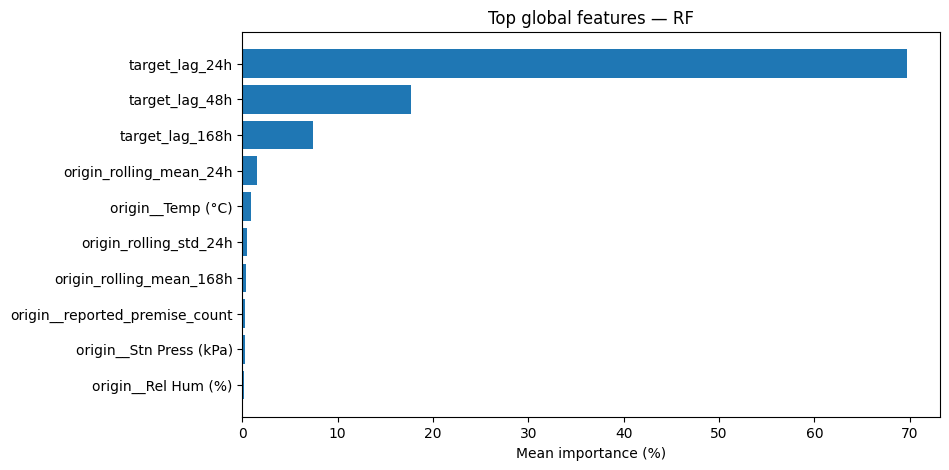

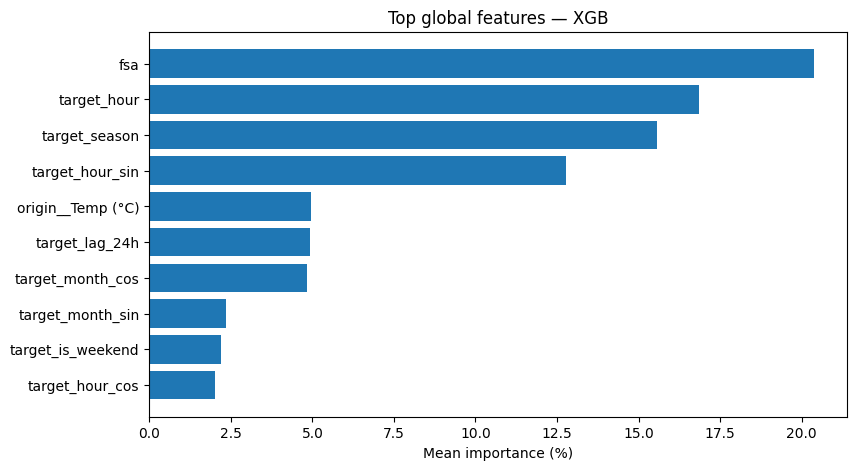

DSA_05 RESULT: COMPLETE


In [11]:
# Plot Top global features
for task in ["rf", "xgb"]:
    top = (
        global_imp[global_imp["task"].eq(task)]
        .nlargest(10, "mean_importance_pct")
        .sort_values("mean_importance_pct")
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top["feature"], top["mean_importance_pct"])
    ax.set_xlabel("Mean importance (%)")
    ax.set_title(f"Top global features — {task.upper()}")
    plt.show()

print("DSA_05 RESULT: COMPLETE")